# Step 2: FinBERT Baseline

In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings('ignore')

import logging
logging.getLogger('transformers').setLevel(logging.ERROR)

DATA_PROC = 'data/processed'
os.makedirs('outputs', exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

## 1. Load Event Dataset

In [ ]:
events      = pd.read_parquet(os.path.join(DATA_PROC, 'events.parquet'))
events_text = pd.read_parquet(os.path.join(DATA_PROC, 'events_text.parquet'))

n_ev_before, n_tx_before = len(events), len(events_text)
events      = events.drop_duplicates(subset='accession').reset_index(drop=True)
events_text = events_text.drop_duplicates(subset='accession').reset_index(drop=True)
if len(events) != n_ev_before:
    print(f'[dedup] events: {n_ev_before} -> {len(events)} rows')
if len(events_text) != n_tx_before:
    print(f'[dedup] events_text: {n_tx_before} -> {len(events_text)} rows')

events['event_date'] = pd.to_datetime(events['event_date'])
events_text['event_date'] = pd.to_datetime(events_text['event_date'])

events = events.merge(events_text[['accession', 'text']], on='accession', how='left')

assert events['accession'].is_unique, \
    f'Row inflation after text merge: {len(events)} rows vs {events["accession"].nunique()} unique'

print(f'Events: {len(events)} rows')
print(events[['ticker', 'form', 'event_date', 'exc_ret_5d', 'exc_ret_20d']].head())

Events: 17032 rows
  ticker  form event_date  exc_ret_5d  exc_ret_20d
0      A  10-Q 2015-03-10    0.002452     0.012093
1      A  10-Q 2015-06-05   -0.013550    -0.010417
2      A  10-Q 2015-09-02    0.003167    -0.035649
3      A  10-K 2015-12-21    0.006197    -0.004766
4      A  10-Q 2016-03-08   -0.012360     0.010674


## 2. FinBERT Sentiment Scoring

ProsusAI/finbert outputs three classes: positive, negative, neutral.  
We define a net sentiment score = P(positive) − P(negative).  
Because filings are much longer than BERT's 512-token limit, we chunk the text
into overlapping windows and average the scores across chunks.

In [ ]:
MODEL_NAME = 'ProsusAI/finbert'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
finbert   = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
finbert   = finbert.to(DEVICE).eval()

id2label = finbert.config.id2label
print('Label map:', id2label)
POS_IDX = [k for k, v in id2label.items() if 'positive' in v.lower()][0]
NEG_IDX = [k for k, v in id2label.items() if 'negative' in v.lower()][0]
print(f'POS idx={POS_IDX}, NEG idx={NEG_IDX}')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Label map: {0: 'positive', 1: 'negative', 2: 'neutral'}
POS idx=0, NEG idx=1


In [ ]:
def score_text_finbert(text: str, chunk_size: int = 400, stride: int = 200,
                       max_chunks: int = 20) -> dict:
    if not text or len(text.strip()) < 50:
        return {'sentiment': 0.0, 'p_pos': 0.33, 'p_neg': 0.33, 'p_neu': 0.34}

    tokens = tokenizer(
        text,
        return_tensors='pt',
        truncation=False,
        add_special_tokens=False,
    )['input_ids'][0]

    chunks = []
    start = 0
    while start < len(tokens) and len(chunks) < max_chunks:
        end = min(start + chunk_size, len(tokens))
        chunks.append(tokens[start:end])
        start += stride

    probs_list = []
    for chunk in chunks:
        input_ids = chunk.unsqueeze(0).to(DEVICE)
        cls_id = tokenizer.cls_token_id
        sep_id = tokenizer.sep_token_id
        input_ids = torch.cat([
            torch.tensor([[cls_id]], device=DEVICE),
            input_ids,
            torch.tensor([[sep_id]], device=DEVICE),
        ], dim=1)[:, :512]

        with torch.no_grad():
            logits = finbert(input_ids).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
        probs_list.append(probs)

    avg = np.mean(probs_list, axis=0)
    return {
        'sentiment': float(avg[POS_IDX] - avg[NEG_IDX]),
        'p_pos':     float(avg[POS_IDX]),
        'p_neg':     float(avg[NEG_IDX]),
        'p_neu':     float(avg[2 - POS_IDX - NEG_IDX]) if len(avg) > 2 else 0.0,
    }

score_cache_path = os.path.join(DATA_PROC, 'finbert_scores.parquet')

if os.path.exists(score_cache_path):
    scores_df = pd.read_parquet(score_cache_path)
    n_before = len(scores_df)
    scores_df = scores_df.drop_duplicates(subset='accession').reset_index(drop=True)
    if len(scores_df) != n_before:
        print(f'[dedup] finbert_scores: {n_before} -> {len(scores_df)} rows')
        scores_df.to_parquet(score_cache_path, index=False)
    print('Loaded cached FinBERT scores.')
else:
    score_records = []
    for _, row in tqdm(events.iterrows(), total=len(events), desc='FinBERT scoring'):
        sc = score_text_finbert(row['text'])
        sc['accession'] = row['accession']
        score_records.append(sc)
    scores_df = pd.DataFrame(score_records).drop_duplicates(subset='accession').reset_index(drop=True)
    scores_df.to_parquet(score_cache_path, index=False)
    print(f'Saved: {score_cache_path}')

events = events.merge(scores_df, on='accession', how='left')

assert events['accession'].is_unique, \
    f'Row inflation after scores merge: {len(events)} rows vs {events["accession"].nunique()} unique'

print('Sentiment score distribution:')
print(events['sentiment'].describe())

Loaded cached FinBERT scores.
Sentiment score distribution:
count    17032.000000
mean        -0.039333
std          0.098487
min         -0.665429
25%         -0.086683
50%         -0.050533
75%         -0.009980
max          0.511052
Name: sentiment, dtype: float64


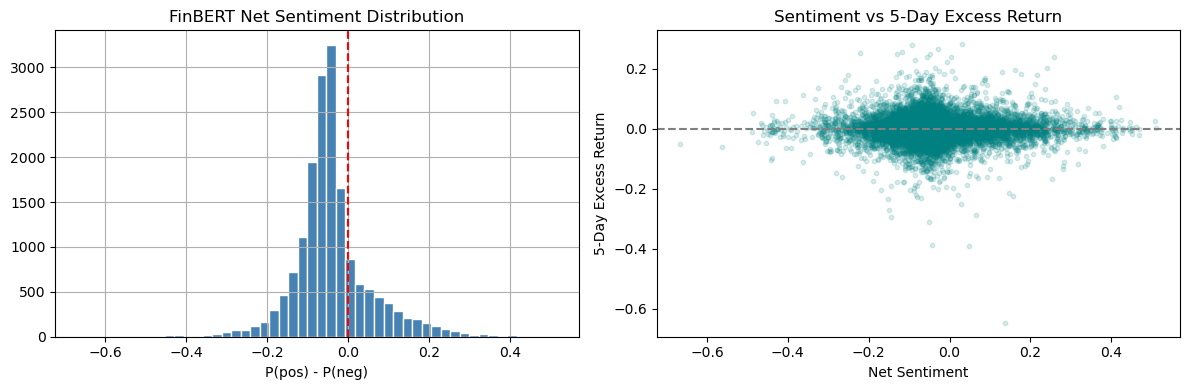

Full-sample Spearman IC (5d): 0.0046  p=0.5442


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
events['sentiment'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('FinBERT Net Sentiment Distribution')
axes[0].set_xlabel('P(pos) - P(neg)')

axes[1].scatter(events['sentiment'], events['exc_ret_5d'], alpha=0.15, s=10, color='teal')
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title('Sentiment vs 5-Day Excess Return')
axes[1].set_xlabel('Net Sentiment')
axes[1].set_ylabel('5-Day Excess Return')

plt.tight_layout()
plt.savefig('outputs/02_sentiment_scatter.png', dpi=150)
plt.show()

ic5, pval5 = spearmanr(events['sentiment'].dropna(), events['exc_ret_5d'].dropna())
print(f'Full-sample Spearman IC (5d): {ic5:.4f}  p={pval5:.4f}')

## 3. Time-Ordered Train/Test Split

Per proposal: time ordering is critical.  
- Train: 2020-01-01 → 2022-12-31  
- Test:  2023-01-01 → 2024-06-30

In [18]:
TRAIN_END = pd.Timestamp('2022-12-31')

train = events[events['event_date'] <= TRAIN_END].copy()
test  = events[events['event_date'] >  TRAIN_END].copy()

print(f'Train: {len(train)} events  ({train.event_date.min().date()} – {train.event_date.max().date()})')
print(f'Test:  {len(test)}  events  ({test.event_date.min().date()}  – {test.event_date.max().date()})')

Train: 14293 events  (2015-02-03 – 2022-12-29)
Test:  2739  events  (2023-01-04  – 2024-06-28)


## 4. Baseline 1: Sentiment-Sorted Quintile Portfolio

At each filing event date, rank all filings by FinBERT sentiment.
Long top quintile (Q5), short bottom quintile (Q1).
Report IC (Spearman correlation of signal with realized excess return).

In [ ]:
def compute_ic_series(df: pd.DataFrame, signal_col: str,
                      label_col: str, freq: str = 'ME') -> pd.Series:
    df = df[['event_date', signal_col, label_col]].dropna().copy()
    df = df.set_index('event_date').sort_index()
    ics = []
    for period, grp in df.resample(freq):
        if len(grp) < 5:
            continue
        ic, _ = spearmanr(grp[signal_col], grp[label_col])
        ics.append({'date': period, 'ic': ic})
    return pd.DataFrame(ics).set_index('date')['ic']


for label, horizon in [('exc_ret_5d', '5-day'), ('exc_ret_20d', '20-day')]:
    ic_series = compute_ic_series(test, 'sentiment', label, freq='QE')
    mean_ic = ic_series.mean()
    icir = mean_ic / (ic_series.std() + 1e-8)
    print(f'Baseline 1 ({horizon}) — Mean IC: {mean_ic:.4f}  ICIR: {icir:.4f}')

Baseline 1 (5-day) — Mean IC: -0.0081  ICIR: -0.3046
Baseline 1 (20-day) — Mean IC: -0.0071  ICIR: -0.1827


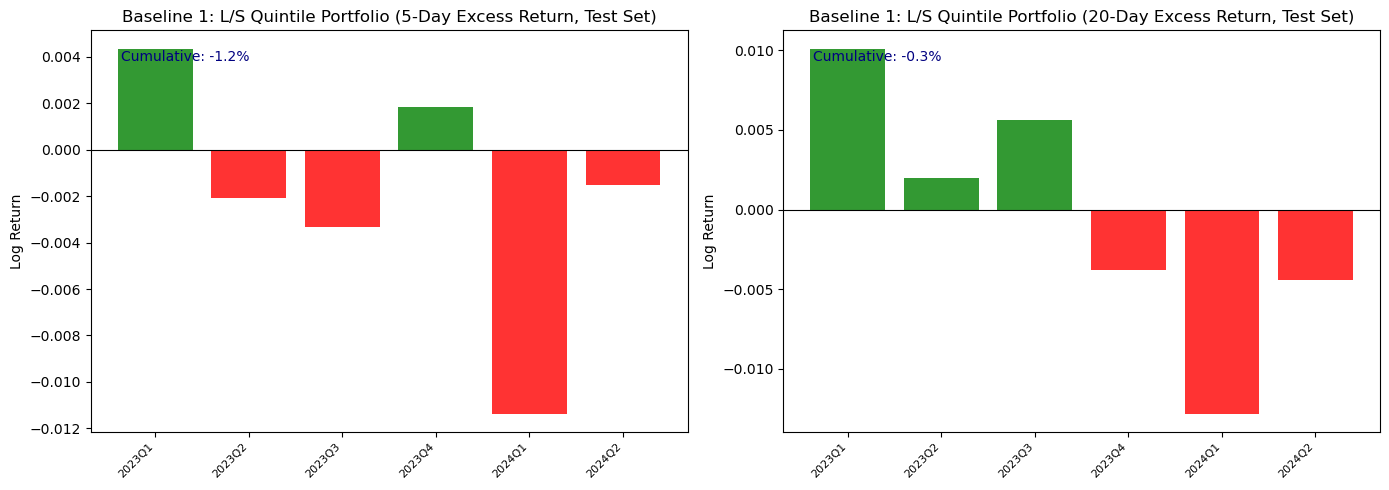

In [ ]:
def quintile_portfolio_returns(df: pd.DataFrame, signal_col: str,
                                label_col: str) -> pd.DataFrame:
    df = df[['event_date', 'ticker', signal_col, label_col]].dropna().copy()
    df = df.sort_values('event_date')
    df['quarter'] = df['event_date'].dt.to_period('Q')

    rows = []
    for q, grp in df.groupby('quarter'):
        if len(grp) < 10:
            continue
        grp = grp.copy()
        grp['rank'] = grp[signal_col].rank(pct=True)
        long_ret  = grp[grp['rank'] >= 0.8][label_col].mean()
        short_ret = grp[grp['rank'] <= 0.2][label_col].mean()
        rows.append({'quarter': str(q), 'long': long_ret, 'short': short_ret,
                     'ls': long_ret - short_ret})
    return pd.DataFrame(rows)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, horizon) in zip(axes, [('exc_ret_5d', '5-Day'), ('exc_ret_20d', '20-Day')]):
    qp = quintile_portfolio_returns(test, 'sentiment', label)
    x  = range(len(qp))
    ax.bar(x, qp['ls'], color=['green' if v > 0 else 'red' for v in qp['ls']], alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(qp['quarter'], rotation=45, ha='right', fontsize=8)
    ax.set_title(f'Baseline 1: L/S Quintile Portfolio ({horizon} Excess Return, Test Set)')
    ax.set_ylabel('Log Return')
    if len(qp):
        cumret = (1 + qp['ls']).prod() - 1
        ax.text(0.05, 0.95, f'Cumulative: {cumret:.1%}', transform=ax.transAxes,
                fontsize=10, va='top', color='navy')

plt.tight_layout()
plt.savefig('outputs/02_baseline1_quintile.png', dpi=150)
plt.show()

## 5. Baseline 2: FinBERT + Market Features → Ridge Regression

In [ ]:
MKT_FEATURE_COLS = [
    'ret_1d_lag', 'ret_5d_lag', 'ret_20d_lag', 'ret_60d_lag',
    'mom_12m_1m', 'rvol_20d', 'rvol_60d', 'vol_zscore_20d',
]
ALL_FEATURES = ['sentiment', 'p_pos', 'p_neg'] + MKT_FEATURE_COLS

results_b2 = {}

for label, horizon in [('exc_ret_5d', '5-day'), ('exc_ret_20d', '20-day')]:
    sub = events[ALL_FEATURES + [label, 'event_date']].dropna().copy()
    sub = sub.sort_values('event_date').reset_index(drop=True)

    X = sub[ALL_FEATURES].values
    y = sub[label].values
    dates = sub['event_date'].values

    train_mask = dates <= np.datetime64(TRAIN_END)
    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[~train_mask], y[~train_mask]
    dates_test = dates[~train_mask]

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    ic, pval = spearmanr(preds, y_test)
    print(f'Baseline 2 ({horizon}) — Out-of-sample Spearman IC: {ic:.4f}  p={pval:.4f}')
    results_b2[horizon] = {'preds': preds, 'actual': y_test, 'dates': dates_test, 'ic': ic}

Baseline 2 (5-day) — Out-of-sample Spearman IC: -0.0422  p=0.0271
Baseline 2 (20-day) — Out-of-sample Spearman IC: 0.0096  p=0.6145


In [ ]:
from scipy import stats as scipy_stats

def newey_west_ic_test(ic_series: np.ndarray, lags: int = 4) -> dict:
    ic = ic_series[~np.isnan(ic_series)]
    n  = len(ic)
    if n < lags + 2:
        return {}
    mean_ic  = ic.mean()
    demeaned = ic - mean_ic
    var0     = (demeaned ** 2).mean()
    acov_sum = sum(
        (1 - lag / (lags + 1)) * (demeaned[:-lag] * demeaned[lag:]).mean()
        for lag in range(1, lags + 1)
    )
    nw_var = (var0 + 2 * acov_sum) / n
    nw_se  = np.sqrt(max(nw_var, 1e-12))
    t_stat = mean_ic / nw_se
    p_val  = 2 * (1 - scipy_stats.t.cdf(abs(t_stat), df=n - 1))
    return {'mean_ic': mean_ic, 'nw_se': nw_se, 't_stat': t_stat,
            'p_value': p_val, 'n_periods': n}


def block_bootstrap_ic(ic_series: np.ndarray, n_boot: int = 2000,
                        block_size: int = 3) -> dict:
    ic = ic_series[~np.isnan(ic_series)]
    n  = len(ic)
    if n < 4:
        return {}
    rng    = np.random.default_rng(42)
    boot_means = []
    for _ in range(n_boot):
        blocks, total = [], 0
        while total < n:
            s = rng.integers(0, max(n - block_size + 1, 1))
            blocks.append(ic[s: s + block_size])
            total += block_size
        sample = np.concatenate(blocks)[:n]
        boot_means.append(sample.mean())
    boot_means = np.array(boot_means)
    ci_lo  = np.percentile(boot_means, 2.5)
    ci_hi  = np.percentile(boot_means, 97.5)
    p_val  = 2 * min((boot_means <= 0).mean(), (boot_means >= 0).mean())
    return {'mean_ic': ic.mean(), 'ci_lower': ci_lo, 'ci_upper': ci_hi,
            'p_value': p_val, 'boot_std': boot_means.std()}

from sklearn.linear_model import Ridge as _Ridge
from sklearn.preprocessing import StandardScaler as _Scaler

MKT_FEATURE_COLS_LOC = [
    'ret_1d_lag', 'ret_5d_lag', 'ret_20d_lag', 'ret_60d_lag',
    'mom_12m_1m', 'rvol_20d', 'rvol_60d', 'vol_zscore_20d',
]
ALL_FEAT_LOC = ['sentiment', 'p_pos', 'p_neg'] + MKT_FEATURE_COLS_LOC

def _make_b2_test_signal(label_col):
    """Train Ridge on train set, return predictions on test set as a column."""
    sub = events[ALL_FEAT_LOC + [label_col, 'event_date']].dropna().copy()
    sub = sub.sort_values('event_date').reset_index(drop=True)
    tm = sub['event_date'] <= TRAIN_END
    sc = _Scaler(); X_tr = sc.fit_transform(sub.loc[tm, ALL_FEAT_LOC])
    X_te = sc.transform(sub.loc[~tm, ALL_FEAT_LOC])
    rr = _Ridge(alpha=1.0); rr.fit(X_tr, sub.loc[tm, label_col])
    out = sub[~tm][['event_date']].copy()
    out['pred_b2'] = rr.predict(X_te)
    out[label_col] = sub.loc[~tm, label_col].values
    return out

b2_test_5d  = _make_b2_test_signal('exc_ret_5d')
b2_test_20d = _make_b2_test_signal('exc_ret_20d')

test = test.copy()
test = test.merge(b2_test_5d[['event_date','pred_b2']].rename(
    columns={'pred_b2':'pred_5d_b2'}), on='event_date', how='left')
test = test.merge(b2_test_20d[['event_date','pred_b2']].rename(
    columns={'pred_b2':'pred_20d_b2'}), on='event_date', how='left')

print('=== IC Significance Tests (Test Set, Monthly IC Series) ===\n')
test_signals_map = [
    ('sentiment',   'Baseline 1 (FinBERT)',      'exc_ret_5d',  '5-day'),
    ('sentiment',   'Baseline 1 (FinBERT)',      'exc_ret_20d', '20-day'),
    ('pred_5d_b2',  'Baseline 2 (Ridge)',        'exc_ret_5d',  '5-day'),
    ('pred_20d_b2', 'Baseline 2 (Ridge)',        'exc_ret_20d', '20-day'),
]

for signal_col, model_name, label_col, horizon in test_signals_map:
    if signal_col not in test.columns:
        continue
    ic_ser = compute_ic_series(test, signal_col, label_col, freq='ME').values
    nw  = newey_west_ic_test(ic_ser, lags=4)
    bb  = block_bootstrap_ic(ic_ser, n_boot=2000, block_size=3)
    if not nw:
        print(f'{model_name} | {horizon}: too few observations (n={len(ic_ser)})')
        continue
    nw_sig  = '*' if nw['p_value'] < 0.05 else ('~' if nw['p_value'] < 0.10 else ' ')
    bb_sig  = '*' if (bb and bb['p_value'] < 0.05) else ('~' if (bb and bb['p_value'] < 0.10) else ' ')
    print(f'{model_name} | {horizon}  (n={nw["n_periods"]} months)')
    print(f'  Mean IC = {nw["mean_ic"]:+.4f} | NW: t={nw["t_stat"]:+.2f}  p={nw["p_value"]:.3f} {nw_sig}')
    if bb:
        print(f'  Bootstrap 95% CI = [{bb["ci_lower"]:+.4f}, {bb["ci_upper"]:+.4f}]  '
              f'p={bb["p_value"]:.3f} {bb_sig}')
    print()

print('* p<0.05  ~ p<0.10')
print('NW: Newey-West HAC (4 lags); Bootstrap: block resampling, block=3 months, 2000 reps')

=== IC Significance Tests (Test Set, Monthly IC Series) ===

Baseline 1 (FinBERT) | 5-day  (n=18 months)
  Mean IC = +0.0042 | NW: t=+0.33  p=0.742  
  Bootstrap 95% CI = [-0.0391, +0.0457]  p=0.794  

Baseline 1 (FinBERT) | 20-day  (n=18 months)
  Mean IC = -0.0822 | NW: t=-1.59  p=0.131  
  Bootstrap 95% CI = [-0.1737, -0.0128]  p=0.025 *

Baseline 2 (Ridge) | 5-day  (n=18 months)
  Mean IC = +0.0064 | NW: t=+0.31  p=0.762  
  Bootstrap 95% CI = [-0.0320, +0.0521]  p=0.620  

Baseline 2 (Ridge) | 20-day  (n=18 months)
  Mean IC = +0.0008 | NW: t=+0.08  p=0.941  
  Bootstrap 95% CI = [-0.0115, +0.0257]  p=0.733  

* p<0.05  ~ p<0.10
NW: Newey-West HAC (4 lags); Bootstrap: block resampling, block=3 months, 2000 reps


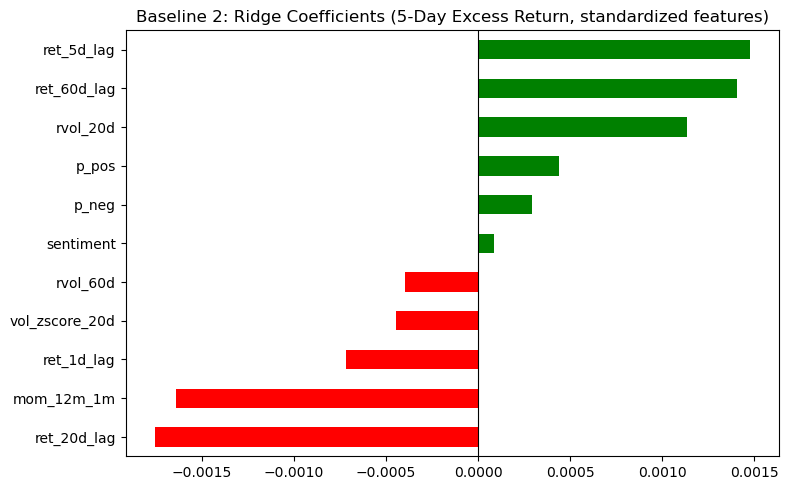

In [ ]:
sub = events[ALL_FEATURES + ['exc_ret_5d', 'event_date']].dropna().copy()
sub = sub.sort_values('event_date').reset_index(drop=True)
train_mask = sub['event_date'] <= TRAIN_END
scaler2 = StandardScaler()
X_all = scaler2.fit_transform(sub[ALL_FEATURES].values)
model2 = Ridge(alpha=1.0)
model2.fit(X_all[train_mask], sub['exc_ret_5d'].values[train_mask])

coef_df = pd.Series(model2.coef_, index=ALL_FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
coef_df.plot.barh(ax=ax, color=['green' if v > 0 else 'red' for v in coef_df])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Baseline 2: Ridge Coefficients (5-Day Excess Return, standardized features)')
plt.tight_layout()
plt.savefig('outputs/02_baseline2_coefs.png', dpi=150)
plt.show()

## 6. Save Enriched Events (with FinBERT scores)

In [24]:
save_cols = [c for c in events.columns if c != 'text']
events[save_cols].to_parquet(
    os.path.join(DATA_PROC, 'events_with_finbert.parquet'), index=False
)
print('Saved: data/processed/events_with_finbert.parquet')

print('\n=== Baseline Summary ===')
print(f'Baseline 1 (sentiment-sorted portfolio): see quintile plots above')
for h, r in results_b2.items():
    print(f'Baseline 2 ({h}): OOS IC = {r["ic"]:.4f}')
print('\nStep 2 complete. Proceed to 03_proposed_model.ipynb')

Saved: data/processed/events_with_finbert.parquet

=== Baseline Summary ===
Baseline 1 (sentiment-sorted portfolio): see quintile plots above
Baseline 2 (5-day): OOS IC = -0.0422
Baseline 2 (20-day): OOS IC = 0.0096

Step 2 complete. Proceed to 03_proposed_model.ipynb
